# Potato Leaf Disease Classification

This notebook classifies potato leaf images into healthy, leafroll virus, and mosaic virus categories using Gaussian Naive Bayes and Random Forest classifiers.

## Expected project structure
```text
potato_leaf_disease_classification/
├── data/
│   ├── dataset/<class_name>/*.jpg
│   └── test_images/sample.jpg
├── models/
├── notebooks/
│   └── checkpoint.ipynb
├── .gitignore
├── README.md
└── requirements.txt
```

**Note:** Dataset images and generated model files are intentionally excluded from Git by `.gitignore`.


# Advanced ML Approach for Early Detection of Viral Diseases in Potato Plants

## Step 1: Importing Required Libraries

In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import numpy as np
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Step 2: Uploading a Image Dataset Path

In [2]:
# Project-relative paths
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
TEST_IMAGE = PROJECT_ROOT / "data" / "test_images" / "sample.jpg"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

path = str(DATASET_DIR)
model_folder = str(MODEL_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}. "
        "Add your dataset under data/dataset/<class_name>/"
    )

categories = sorted([
    d for d in os.listdir(path)
    if os.path.isdir(os.path.join(path, d))
])
categories


['Potato___healthy', 'Potato___leafroll_virus', 'Potato___mosaic_virus']

## Step 3: Image Pre-processing

### 3.1 Converting Image into Arrays

In [3]:
model_folder = str(MODEL_DIR)
X_file = os.path.join(model_folder, "X.txt.npy")
Y_file = os.path.join(model_folder, "Y.txt.npy")
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("X and Y arrays loaded successfully.")
else:
    X = [] # input array
    Y = [] # output array
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            print(f'Loading category: {dirs}')
            print(name+" "+root+"/"+directory[j])
            if 'Thumbs.db' not in directory[j]:
                img_array = cv2.imread(root+"/"+directory[j])
                img_resized = resize(img_array, (64, 64, 3))
                # Append the input image array to X
                X.append(img_resized.flatten())
                # Append the index of the category in categories list to Y
                Y.append(categories.index(name))
    X = np.array(X)
    Y = np.array(Y)
    np.save(X_file, X)
    np.save(Y_file, Y)

X and Y arrays loaded successfully.


In [4]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Labels
0,0.512223,0.519816,0.524488,0.512237,0.518048,0.528067,0.512144,0.516155,0.531574,0.514473,...,0.198548,0.216589,0.212668,0.194229,0.213836,0.206914,0.185099,0.205410,0.198356,0
1,0.525553,0.562918,0.597177,0.530248,0.565637,0.600884,0.526486,0.561781,0.597075,0.526187,...,0.194934,0.218512,0.238201,0.196346,0.220548,0.240211,0.194478,0.219012,0.236742,0
2,0.566703,0.592629,0.612536,0.564485,0.586867,0.611566,0.558543,0.579551,0.609449,0.558691,...,0.216620,0.241983,0.257679,0.220870,0.246123,0.258799,0.203602,0.229824,0.242929,0
3,0.470787,0.498542,0.508849,0.466270,0.492608,0.506579,0.466028,0.490182,0.508540,0.464607,...,0.281390,0.303533,0.304650,0.266091,0.295680,0.295518,0.258073,0.289425,0.286116,0
4,0.437245,0.464694,0.476461,0.444281,0.471562,0.483666,0.452062,0.478819,0.491971,0.445825,...,0.260655,0.282872,0.279375,0.243902,0.265966,0.265323,0.233546,0.259364,0.260439,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,0.023295,0.022328,0.024353,0.024568,0.024942,0.025985,0.024846,0.027530,0.028745,0.026763,...,0.034348,0.038190,0.041573,0.031100,0.035226,0.037657,0.031598,0.033466,0.035307,2
791,0.021864,0.021716,0.026633,0.024233,0.024765,0.028072,0.025765,0.028270,0.029546,0.024441,...,0.029334,0.031774,0.035091,0.030334,0.033572,0.036164,0.028432,0.032288,0.034707,2
792,0.031858,0.034838,0.035226,0.034766,0.037552,0.038517,0.035180,0.041642,0.043188,0.037864,...,0.038863,0.042520,0.047209,0.036945,0.039168,0.043945,0.033772,0.035538,0.040630,2
793,0.030867,0.032893,0.035231,0.032633,0.037187,0.039947,0.035592,0.041272,0.043370,0.038963,...,0.039483,0.046349,0.049762,0.036585,0.042535,0.045502,0.034382,0.039182,0.042690,2


In [5]:
df.Labels.unique()

array([0, 1, 2], dtype=int64)

## Step 4: Applying EAD - Exploratory Data Analysis

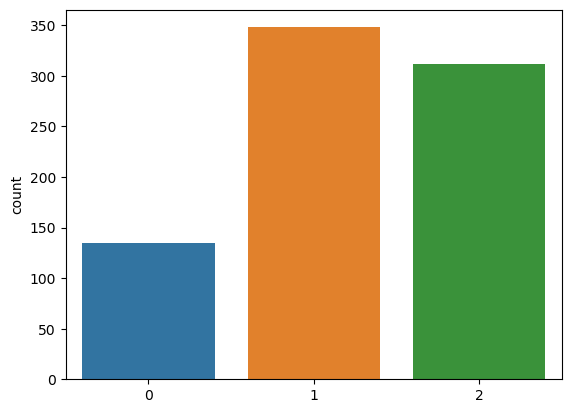

In [6]:
sns.countplot(x = Y)
plt.show()

## Step 5: Splitting Data into Two Ways - Train Data and Test Data

In [7]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=77)

In [8]:
x_train.shape

(556, 12288)

In [9]:
y_train.shape

(556,)

In [10]:
accuracy = []
precision = []
fscore = []
recall = []
labels = ['Potato_leafroll_virus', 'Potato_healthy', 'Potato_mosaic_virus']

In [11]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

## Step 6: Model Building and Training

### 6.1 Gaussian Naive Bayes

Naive Bayes Accuracy    : 64.01673640167364
Naive Bayes Precision   : 70.66641471403376
Naive Bayes Recall      : 71.09710971097111
Naive Bayes FSCORE      : 64.14322107939066

 Naive Bayes classification report
                        precision    recall  f1-score   support

Potato_leafroll_virus       1.00      0.80      0.89        49
       Potato_healthy       0.21      0.75      0.33        28
  Potato_mosaic_virus       0.92      0.57      0.71       162

             accuracy                           0.64       239
            macro avg       0.71      0.71      0.64       239
         weighted avg       0.85      0.64      0.70       239



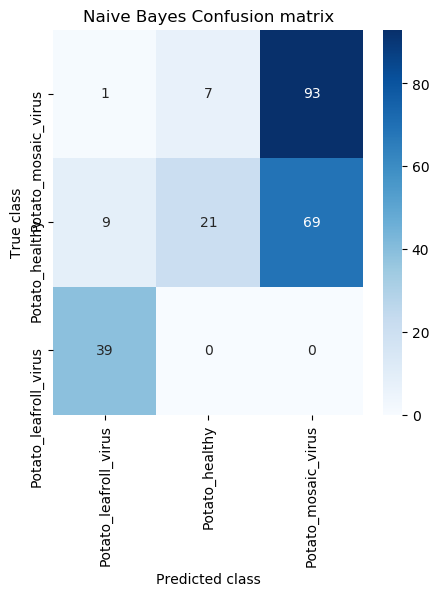

In [12]:
from sklearn.naive_bayes import GaussianNB
model = str(MODEL_DIR / "naive_bayes.pkl")
if os.path.exists(model):
    # Load the model from the pkl file
    naive_bayes = joblib.load(model)
    predict = naive_bayes.predict(x_test)
    calculateMetrics("Naive Bayes", predict, y_test)
else:
    naive_bayes = GaussianNB()
    # Train the classifier on the training data
    naive_bayes.fit(x_train, y_train)
    # Make predictions on the test data
    predict = naive_bayes.predict(x_test)
    joblib.dump(naive_bayes, model)
    print("Naive Bayes trained and model weights saved.")
    calculateMetrics("Naive Bayes", predict, y_test)


### 6.2 Random Forest Classifier

Random Forest Accuracy    : 95.39748953974896
Random Forest Precision   : 96.08024691358025
Random Forest Recall      : 96.36296963029636
Random Forest FSCORE      : 96.0706114066736

 Random Forest classification report
                        precision    recall  f1-score   support

Potato_leafroll_virus       1.00      0.97      0.99        40
       Potato_healthy       0.99      0.91      0.95       108
  Potato_mosaic_virus       0.90      1.00      0.95        91

             accuracy                           0.95       239
            macro avg       0.96      0.96      0.96       239
         weighted avg       0.96      0.95      0.95       239



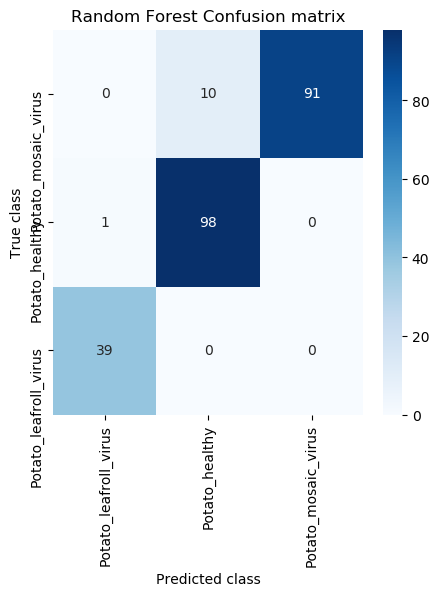

In [13]:
model = str(MODEL_DIR / "random_forest.pkl")
if os.path.exists(model):
    random_forest = joblib.load(model)
    predict = random_forest.predict(x_test)
    calculateMetrics("Random Forest", predict, y_test)
else:
    random_forest = RandomForestClassifier(n_estimators=200, random_state=42)
    random_forest.fit(x_train, y_train)
    predict = random_forest.predict(x_test)
    joblib.dump(random_forest, model)
    print("Random Forest trained and model weights saved.")
    calculateMetrics("Random Forest", predict, y_test)


## Step 7: Uploading a Image Path for Testing

### 7.1 Image Pre-processing 

### 7.2 Prediction on Image Data

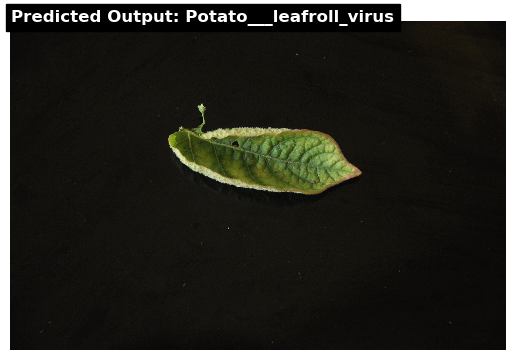

In [16]:
# Select a test image from data/test_images/
if not TEST_IMAGE.exists():
    raise FileNotFoundError(
        f"Test image not found: {TEST_IMAGE}. "
        "Add a JPG/PNG image to data/test_images/ and update TEST_IMAGE if needed."
    )

path = str(TEST_IMAGE)
img = imread(path)
img_resize = resize(img, (64, 64, 3))
img_preprocessed = [img_resize.flatten()]
output_number = random_forest.predict(img_preprocessed)[0]
output_name = categories[output_number]

plt.imshow(img)
plt.text(
    10, 10, f"Predicted Output: {output_name}",
    color="white", fontsize=12, weight="bold", backgroundcolor="black"
)
plt.axis("off")
plt.show()
